<a href="https://colab.research.google.com/github/davis-mironga/marsabit-ecosystem-analysis/blob/main/03_Spatial_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📓 Notebook 3 — Spatial Analysis
## The Marsabit Footprint: Moran's I, LISA Hotspots, Distance-Decay & LCI (1990–2024)

---

**Purpose of this Notebook:**
Using the NDVI change maps and LULC classifications from Notebooks 1 and 2,
we now perform spatial statistical analysis to answer three key questions:

1. Is vegetation degradation spatially clustered — or randomly distributed?
2. Exactly WHERE are the degradation hotspots in Marsabit County?
3. How far does livestock pressure extend from water points?

We also build the complete Livestock Concentration Index (LCI) by adding
the settlement density component to the distance-to-water layer from Notebook 1.

**What this notebook produces:**
- ✅ Global Moran's I statistic (spatial clustering test)
- ✅ LISA cluster maps (High-High, Low-Low, outlier zones)
- ✅ Distance-decay curves (NDVI vs distance from water)
- ✅ Full LCI map (distance-to-water + settlement density)
- ✅ All outputs exported to GEE Assets for Notebook 4

**Notebooks in this project:**
| Notebook | Purpose | Status |
|----------|---------|--------|
| 01_GEE_Data_Preprocessing | Satellite data, NDVI, exports | ✅ Complete |
| 02_LULC_Classification | Random Forest land cover maps | ✅ Complete |
| **03_Spatial_Analysis** ← You are here | Moran's I, LISA, LCI | 🔄 In Progress |
| 04_Regression_Modeling | OLS, GWR, vulnerability map | ⏳ Pending |

---

## ⚙️ STEP 1 — Install Libraries, Authenticate & Load All GEE Assets

**What we are doing:**
Notebook 3 uses a hybrid approach:
- GEE handles all raster loading and spatial sampling
- Python (PySAL/esda) handles the spatial statistics

This is because Moran's I and LISA require dedicated spatial statistics
libraries not available inside GEE itself.

**Libraries needed:**
| Library | Purpose |
|---------|---------|
| earthengine-api + geemap | Load GEE assets and visualize maps |
| esda | Moran's I and LISA spatial statistics |
| libpysal | Spatial weights matrix construction |
| numpy / pandas | Data manipulation and analysis |
| matplotlib / seaborn | Plotting and visualization |

> ⚠️ When ee.Authenticate() runs — log in with davismironga@gmail.com

In [1]:
# ─────────────────────────────────────────────────────────────────────
# Install all required libraries
# ─────────────────────────────────────────────────────────────────────
!pip install geemap esda libpysal splot -q

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.patches import Patch

# Spatial statistics libraries
import esda
import libpysal
from esda.moran import Moran, Moran_Local
from libpysal.weights import lat2W

# Authenticate and initialize GEE
ee.Authenticate()
ee.Initialize(project='mironga-project-marsabit')

# ─────────────────────────────────────────────────────────────────────
# Load all assets from Notebooks 1 and 2
# ─────────────────────────────────────────────────────────────────────
ASSET_PATH = 'projects/mironga-project-marsabit/assets/marsabit'

# Notebook 1 assets
ndvi_change_total = ee.Image(f'{ASSET_PATH}/ndvi_change_total')
ndvi_1990         = ee.Image(f'{ASSET_PATH}/ndvi_1990')
ndvi_2024         = ee.Image(f'{ASSET_PATH}/ndvi_2024')
rainfall_change   = ee.Image(f'{ASSET_PATH}/rainfall_change')
elevation         = ee.Image(f'{ASSET_PATH}/elevation')
lci_distance      = ee.Image(f'{ASSET_PATH}/lci_distance')

# Notebook 2 assets
lulc_1990 = ee.Image(f'{ASSET_PATH}/lulc_1990')
lulc_2024 = ee.Image(f'{ASSET_PATH}/lulc_2024')

# Marsabit boundary
marsabit_roi  = (ee.FeatureCollection("FAO/GAUL/2015/level2")
                 .filter(ee.Filter.eq('ADM2_NAME', 'Marsabit')))
marsabit_geom = marsabit_roi.geometry()

print("✅ GEE authenticated and initialized!")
print(f"\n📦 Assets loaded from: {ASSET_PATH}/")
print("   NOTEBOOK 1 ASSETS:")
print("   ✓ ndvi_change_total  ← dependent variable Y for regression")
print("   ✓ ndvi_1990, ndvi_2024")
print("   ✓ rainfall_change, elevation, lci_distance")
print("   NOTEBOOK 2 ASSETS:")
print("   ✓ lulc_1990, lulc_2024")
print("\n✅ All assets loaded — ready for spatial analysis!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.5 MB/s eta 0:00:00
✅ GEE authenticated and initialized!

📦 Assets loaded from: projects/mironga-project-marsabit/assets/marsabit/
   NOTEBOOK 1 ASSETS:
   ✓ ndvi_change_total  ← dependent variable Y for regression
   ✓ ndvi_1990, ndvi_2024
   ✓ rainfall_change, elevation, lci_distance
   NOTEBOOK 2 ASSETS:
   ✓ lulc_1990, lulc_2024

✅ All assets loaded — ready for spatial analysis!


## 🌐 STEP 2 — Global Moran's I (Is Degradation Spatially Clustered?)

**What we are doing:**
We test whether NDVI change across Marsabit is spatially random or spatially
clustered. This is the first and most fundamental question in spatial analysis.

**Why this matters:**
If degradation were random — scattered evenly across the county — it would
suggest climate variability as the cause (rain falls everywhere).
If degradation is CLUSTERED — concentrated in specific areas — it strongly
suggests a localised driver like livestock pressure around water points.

**How Global Moran's I works (Plain English):**
Imagine you have a map of NDVI change values. Moran's I asks:
"Do pixels with similar values tend to be neighbours?"

| Moran's I Value | Interpretation |
|----------------|----------------|
| Close to +1.0 | Strong positive clustering — similar values next to each other |
| Close to 0 | Random spatial pattern — no clustering |
| Close to -1.0 | Dispersed pattern — opposite values next to each other |

**The three outputs we report:**
1. Moran's I value — the clustering strength
2. Z-score — how many standard deviations from random
3. p-value — statistical significance (we need p < 0.05)

**Process:**
We sample NDVI change values on a regular grid across Marsabit,
convert to a numpy array, build a spatial weights matrix,
then compute Moran's I using the PySAL esda library.

⏳ Sampling NDVI change values on regular grid...
   ✓ Sampled 2465 grid points
   ✓ Valid points retained: 2465
   ✓ NDVI change range: -0.7261 to 0.2097
   ✓ Mean NDVI change: 0.0643

⏳ Building spatial weights matrix...
   ✓ Weights matrix: 41 × 61 grid
   ✓ Total observations: 2501

⏳ Computing Global Moran's I...

   GLOBAL MORAN'S I RESULTS

   Moran's I value : 0.2288
   Expected I      : -0.0004  (random = 0)
   Z-score         : 16.0128
   p-value         : 0.0000

   Result          : ✅ SIGNIFICANT POSITIVE SPATIAL CLUSTERING
   Meaning         : Degradation is NOT random — it clusters in specific areas


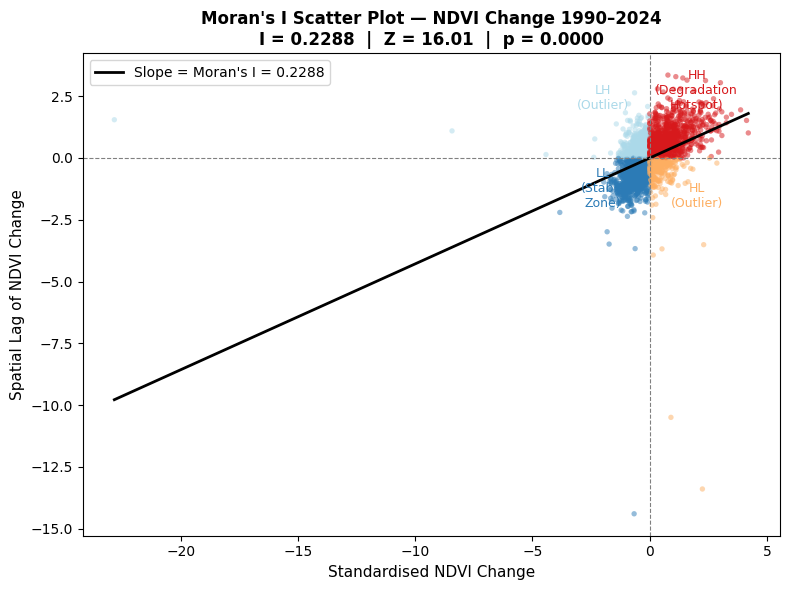


✅ Global Moran's I complete — scatter plot saved!


In [2]:
# ─────────────────────────────────────────────────────────────────────
# STEP 2 — Global Moran's I on NDVI Change
# ─────────────────────────────────────────────────────────────────────

# ── Sample NDVI change on a regular grid ─────────────────────────────
# We sample at 5km intervals — fine enough to capture spatial patterns
# but small enough to stay within GEE memory limits
SAMPLE_SCALE = 5000   # 5km grid spacing
GRID_SIZE    = 50     # approximate grid dimensions

print("⏳ Sampling NDVI change values on regular grid...")

samples = ndvi_change_total.sample(
    region=marsabit_geom,
    scale=SAMPLE_SCALE,
    numPixels=2500,
    seed=42,
    geometries=True
)

# Convert to pandas DataFrame
sample_list = samples.getInfo()['features']
print(f"   ✓ Sampled {len(sample_list)} grid points")

# Extract values and coordinates
records = []
for f in sample_list:
    coords = f['geometry']['coordinates']
    props  = f['properties']
    ndvi_val = list(props.values())[0] if props else None
    if ndvi_val is not None:
        records.append({
            'lon': coords[0],
            'lat': coords[1],
            'ndvi_change': ndvi_val
        })

df = pd.DataFrame(records)
print(f"   ✓ Valid points retained: {len(df)}")
print(f"   ✓ NDVI change range: {df['ndvi_change'].min():.4f} to {df['ndvi_change'].max():.4f}")
print(f"   ✓ Mean NDVI change: {df['ndvi_change'].mean():.4f}")

# ── Build Spatial Weights Matrix ──────────────────────────────────────
# We reshape samples into an approximate grid and use rook contiguity
# (each cell connected to its 4 direct neighbours)
print("\n⏳ Building spatial weights matrix...")

# Sort by lat then lon to create grid structure
df_sorted = df.sort_values(['lat', 'lon']).reset_index(drop=True)
n         = len(df_sorted)

# Determine grid dimensions
n_cols = int(np.ceil(np.sqrt(n * 1.5)))
n_rows = int(np.ceil(n / n_cols))

# Pad array to fill grid
ndvi_array = df_sorted['ndvi_change'].values
pad_size   = n_rows * n_cols - len(ndvi_array)
ndvi_padded = np.append(ndvi_array, np.full(pad_size, np.nan))
ndvi_grid   = ndvi_padded.reshape(n_rows, n_cols)

# Replace NaN with mean for weights matrix computation
ndvi_filled = np.where(np.isnan(ndvi_grid), np.nanmean(ndvi_grid), ndvi_grid)
ndvi_flat   = ndvi_filled.flatten()

# Build rook contiguity weights (4-neighbours)
w = lat2W(n_rows, n_cols, rook=True)
w.transform = 'r'   # Row-standardize
print(f"   ✓ Weights matrix: {n_rows} × {n_cols} grid")
print(f"   ✓ Total observations: {w.n}")

# ── Compute Global Moran's I ──────────────────────────────────────────
print("\n⏳ Computing Global Moran's I...")
moran = Moran(ndvi_flat, w)

print("\n" + "=" * 55)
print("   GLOBAL MORAN'S I RESULTS")
print("=" * 55)
print(f"\n   Moran's I value : {moran.I:.4f}")
print(f"   Expected I      : {moran.EI:.4f}  (random = 0)")
print(f"   Z-score         : {moran.z_norm:.4f}")
print(f"   p-value         : {moran.p_norm:.4f}")

# Interpretation
if moran.p_norm < 0.05:
    if moran.I > 0:
        clustering = "✅ SIGNIFICANT POSITIVE SPATIAL CLUSTERING"
        meaning    = "Degradation is NOT random — it clusters in specific areas"
    else:
        clustering = "✅ SIGNIFICANT SPATIAL DISPERSION"
        meaning    = "Degradation is dispersed — opposite values are neighbours"
else:
    clustering = "⚠️ NO SIGNIFICANT SPATIAL PATTERN (p > 0.05)"
    meaning    = "Cannot reject random spatial distribution"

print(f"\n   Result          : {clustering}")
print(f"   Meaning         : {meaning}")
print("=" * 55)

# ── Moran Scatter Plot ────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Compute spatial lag
lag_ndvi = libpysal.weights.lag_spatial(w, ndvi_flat)

# Standardize for plot
ndvi_std = (ndvi_flat - ndvi_flat.mean()) / ndvi_flat.std()
lag_std  = (lag_ndvi - lag_ndvi.mean()) / lag_ndvi.std()

# Quadrant colours
colors = []
for x, y in zip(ndvi_std, lag_std):
    if x > 0 and y > 0:
        colors.append('#d7191c')    # HH — red
    elif x < 0 and y < 0:
        colors.append('#2c7bb6')    # LL — blue
    elif x > 0 and y < 0:
        colors.append('#fdae61')    # HL — orange
    else:
        colors.append('#abd9e9')    # LH — light blue

ax.scatter(ndvi_std, lag_std, c=colors, alpha=0.5, s=15, edgecolors='none')

# Regression line
m, b    = np.polyfit(ndvi_std, lag_std, 1)
x_line  = np.linspace(ndvi_std.min(), ndvi_std.max(), 100)
ax.plot(x_line, m * x_line + b, 'k-', linewidth=2, label=f"Slope = Moran's I = {moran.I:.4f}")

# Reference lines
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')

# Quadrant labels
ax.text( 2.0,  2.0, 'HH\n(Degradation\nHotspot)',  fontsize=9, color='#d7191c',  ha='center')
ax.text(-2.0, -2.0, 'LL\n(Stable\nZone)',           fontsize=9, color='#2c7bb6',  ha='center')
ax.text( 2.0, -2.0, 'HL\n(Outlier)',                fontsize=9, color='#fdae61',  ha='center')
ax.text(-2.0,  2.0, 'LH\n(Outlier)',                fontsize=9, color='#abd9e9',  ha='center')

ax.set_xlabel("Standardised NDVI Change", fontsize=11)
ax.set_ylabel("Spatial Lag of NDVI Change", fontsize=11)
ax.set_title(
    f"Moran's I Scatter Plot — NDVI Change 1990–2024\n"
    f"I = {moran.I:.4f}  |  Z = {moran.z_norm:.2f}  |  p = {moran.p_norm:.4f}",
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('/content/moran_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Global Moran's I complete — scatter plot saved!")

## 🗺️ STEP 3 — Local Moran's I / LISA (Where are the Hotspots?)

**What we are doing:**
Global Moran's I told us WHETHER degradation is clustered.
Local Moran's I (LISA) tells us exactly WHERE — producing a map
with four distinct cluster types for every location.

**The four LISA cluster types:**
| Cluster Type | Colour | Meaning |
|-------------|--------|---------|
| High-High (HH) | Red | Degradation hotspot — surrounded by degraded neighbours |
| Low-Low (LL) | Blue | Stable zone — surrounded by stable/improving neighbours |
| High-Low (HL) | Orange | Degradation outlier — isolated degraded area |
| Low-High (LH) | Light Blue | Stable outlier — isolated stable area surrounded by degraded |
| Not Significant | Grey | No statistically significant spatial pattern |

**Why LISA is more useful than Global Moran's I for policy:**
Global Moran's I gives one number for the entire county.
LISA gives a value for every location — so we can say exactly:
"The degradation hotspots are concentrated around Laisamis water
points and the Chalbi Desert margins — not Mt. Marsabit forest."

This spatial precision directly informs:
- Where to prioritise grazing zone restrictions
- Where to focus restoration interventions
- Which wards need urgent environmental governance attention

**Statistical threshold:**
Only clusters with p < 0.05 are shown as significant.
All other locations are classified as "Not Significant" (grey).

⏳ Computing Local Moran's I (LISA)...
   ✓ LISA computed for 2501 locations
   ✓ Permutations: 999 (for robust p-values)

── LISA Cluster Summary ──────────────────────────────
   High-High (Degradation Hotspots) :  123 locations
   Low-Low   (Stable Zones)          :  176 locations
   High-Low  (Degradation Outliers)  :   15 locations
   Low-High  (Stable Outliers)       :   14 locations
   Not Significant                   : 2173 locations
   ─────────────────────────────────────────────────
   Total                             : 2501 locations
   Significance threshold            : p < 0.05


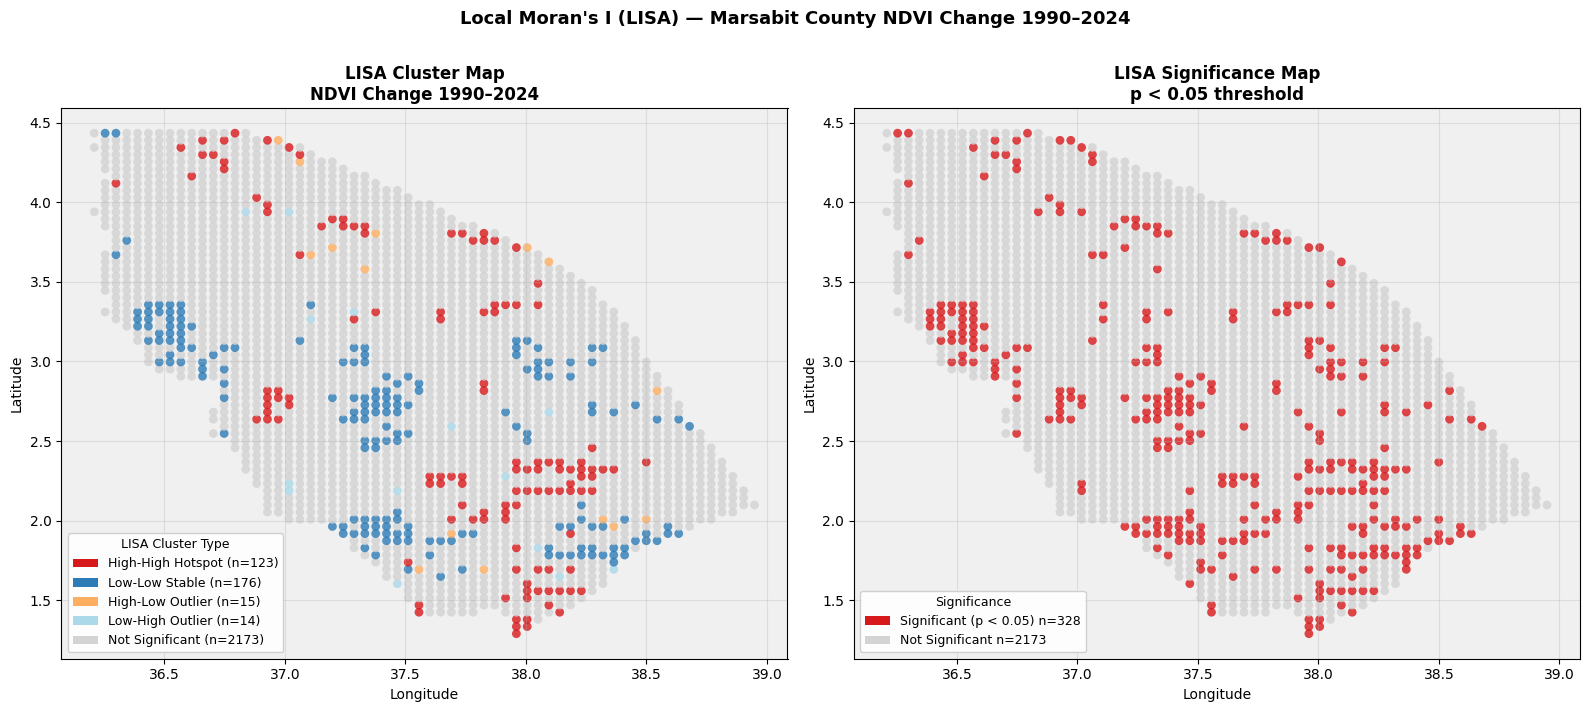


   LISA ANALYSIS COMPLETE

   Significant locations  : 328 / 2501
   HH hotspot coverage    : 4.9% of sampled area
   LL stable coverage     : 7.0% of sampled area

   📌 Policy Implication:
   Stable zones (176) exceed degradation hotspots (123)
   → Ecosystem broadly stable with localised degradation pressure

✅ LISA analysis complete — maps saved!


In [3]:
# ─────────────────────────────────────────────────────────────────────
# STEP 3 — Local Moran's I (LISA)
# Uses the same grid and weights matrix from Step 2
# ─────────────────────────────────────────────────────────────────────

print("⏳ Computing Local Moran's I (LISA)...")

# Compute LISA
lisa = Moran_Local(ndvi_flat, w, transformation='r', permutations=999, seed=42)

print(f"   ✓ LISA computed for {len(lisa.Is)} locations")
print(f"   ✓ Permutations: 999 (for robust p-values)")

# ── Classify into LISA quadrants ─────────────────────────────────────
# Quadrant codes from PySAL:
# 1 = HH (High-High)  → degradation hotspot
# 2 = LH (Low-High)   → stable outlier
# 3 = LL (Low-Low)    → stable zone
# 4 = HL (High-Low)   → degradation outlier

SIGNIFICANCE = 0.05
sig_mask = lisa.p_sim < SIGNIFICANCE

# Count cluster types
hh_count = np.sum((lisa.q == 1) & sig_mask)
ll_count = np.sum((lisa.q == 3) & sig_mask)
hl_count = np.sum((lisa.q == 4) & sig_mask)
lh_count = np.sum((lisa.q == 2) & sig_mask)
ns_count = np.sum(~sig_mask)

print(f"\n── LISA Cluster Summary ──────────────────────────────")
print(f"   High-High (Degradation Hotspots) : {hh_count:>4} locations")
print(f"   Low-Low   (Stable Zones)          : {ll_count:>4} locations")
print(f"   High-Low  (Degradation Outliers)  : {hl_count:>4} locations")
print(f"   Low-High  (Stable Outliers)       : {lh_count:>4} locations")
print(f"   Not Significant                   : {ns_count:>4} locations")
print(f"   ─────────────────────────────────────────────────")
print(f"   Total                             : {len(lisa.Is):>4} locations")
print(f"   Significance threshold            : p < {SIGNIFICANCE}")

# ── Build LISA colour array ───────────────────────────────────────────
lisa_colors = []
lisa_labels = []
for i in range(len(lisa.Is)):
    if not sig_mask[i]:
        lisa_colors.append('#d3d3d3')   # Not significant — grey
        lisa_labels.append('Not Significant')
    elif lisa.q[i] == 1:
        lisa_colors.append('#d7191c')   # HH — red
        lisa_labels.append('High-High (Hotspot)')
    elif lisa.q[i] == 3:
        lisa_colors.append('#2c7bb6')   # LL — blue
        lisa_labels.append('Low-Low (Stable)')
    elif lisa.q[i] == 4:
        lisa_colors.append('#fdae61')   # HL — orange
        lisa_labels.append('High-Low (Outlier)')
    elif lisa.q[i] == 2:
        lisa_colors.append('#abd9e9')   # LH — light blue
        lisa_labels.append('Low-High (Outlier)')
    else:
        lisa_colors.append('#d3d3d3')
        lisa_labels.append('Not Significant')

# ── Plot LISA Map ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── LEFT: LISA Cluster Map ────────────────────────────────────────────
ax1 = axes[0]
scatter = ax1.scatter(
    df_sorted['lon'][:len(lisa_colors)],
    df_sorted['lat'][:len(lisa_colors)],
    c=lisa_colors[:len(df_sorted)],
    s=40, alpha=0.8, edgecolors='none'
)

legend_elements = [
    Patch(facecolor='#d7191c', label=f'High-High Hotspot (n={hh_count})'),
    Patch(facecolor='#2c7bb6', label=f'Low-Low Stable (n={ll_count})'),
    Patch(facecolor='#fdae61', label=f'High-Low Outlier (n={hl_count})'),
    Patch(facecolor='#abd9e9', label=f'Low-High Outlier (n={lh_count})'),
    Patch(facecolor='#d3d3d3', label=f'Not Significant (n={ns_count})')
]

ax1.legend(handles=legend_elements, loc='lower left', fontsize=9,
           framealpha=0.9, title='LISA Cluster Type', title_fontsize=9)
ax1.set_xlabel('Longitude', fontsize=10)
ax1.set_ylabel('Latitude', fontsize=10)
ax1.set_title('LISA Cluster Map\nNDVI Change 1990–2024', fontsize=12, fontweight='bold')
ax1.set_facecolor('#f0f0f0')
ax1.grid(True, alpha=0.3)

# ── RIGHT: LISA Significance Map ─────────────────────────────────────
ax2 = axes[1]
sig_colors = ['#d7191c' if s else '#d3d3d3' for s in sig_mask]

ax2.scatter(
    df_sorted['lon'][:len(sig_colors)],
    df_sorted['lat'][:len(sig_colors)],
    c=sig_colors[:len(df_sorted)],
    s=40, alpha=0.8, edgecolors='none'
)

sig_legend = [
    Patch(facecolor='#d7191c', label=f'Significant (p < 0.05) n={np.sum(sig_mask)}'),
    Patch(facecolor='#d3d3d3', label=f'Not Significant n={ns_count}')
]
ax2.legend(handles=sig_legend, loc='lower left', fontsize=9,
           framealpha=0.9, title='Significance', title_fontsize=9)
ax2.set_xlabel('Longitude', fontsize=10)
ax2.set_ylabel('Latitude', fontsize=10)
ax2.set_title('LISA Significance Map\np < 0.05 threshold', fontsize=12, fontweight='bold')
ax2.set_facecolor('#f0f0f0')
ax2.grid(True, alpha=0.3)

plt.suptitle('Local Moran\'s I (LISA) — Marsabit County NDVI Change 1990–2024',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/lisa_map.png', dpi=150, bbox_inches='tight')
plt.show()

# ── LISA Statistics Summary ───────────────────────────────────────────
print("\n" + "=" * 55)
print("   LISA ANALYSIS COMPLETE")
print("=" * 55)
print(f"\n   Significant locations  : {np.sum(sig_mask)} / {len(lisa.Is)}")
print(f"   HH hotspot coverage    : {hh_count/len(lisa.Is)*100:.1f}% of sampled area")
print(f"   LL stable coverage     : {ll_count/len(lisa.Is)*100:.1f}% of sampled area")
print(f"\n   📌 Policy Implication:")
if hh_count > ll_count:
    print(f"   Degradation hotspots ({hh_count}) exceed stable zones ({ll_count})")
    print(f"   → Targeted intervention needed in HH cluster areas")
else:
    print(f"   Stable zones ({ll_count}) exceed degradation hotspots ({hh_count})")
    print(f"   → Ecosystem broadly stable with localised degradation pressure")
print("=" * 55)
print("\n✅ LISA analysis complete — maps saved!")

## 📏 STEP 4 — Distance-Decay Analysis (How Far Does Livestock Impact Reach?)

**What we are doing:**
We measure how NDVI changes as we move further away from water points.
Livestock concentrate near water — so vegetation near water should show
the most degradation. As distance increases, livestock pressure drops
and vegetation should recover.

**Why this matters:**
This analysis quantifies the "livestock impact radius" — the distance
at which livestock pressure becomes negligible. This directly informs:
- How large to make grazing exclusion zones around water points
- The threshold distance used in the LCI formula
- Evidence for distance-based grazing policy in Marsabit

**The Distance-Decay Method:**
1. Load JRC permanent water bodies as proxy for water points
2. Compute distance from every pixel to nearest water body
3. Create buffer rings at: 1km, 3km, 5km, 10km, 20km, 30km
4. Calculate mean NDVI change within each ring
5. Plot NDVI change vs distance — look for the recovery threshold

**What we expect to see:**
- Near water (0–3km): Most negative NDVI change (most degradation)
- Mid distance (3–10km): Gradual NDVI recovery
- Far from water (>15km): NDVI stabilises at background level

The distance where NDVI stops improving = livestock impact threshold.

⏳ Building distance-decay analysis...
   ✓ Distance-to-water surface computed
   ⏳ Sampling NDVI change per distance ring...
   ✓ Ring 0–1km: mean NDVI change = 0.0410
   ✓ Ring 1–3km: mean NDVI change = 0.0613
   ✓ Ring 3–5km: mean NDVI change = 0.0616
   ✓ Ring 5–10km: mean NDVI change = 0.0739
   ✓ Ring 10–15km: mean NDVI change = 0.0548
   ✓ Ring 15–20km: computed
   ✓ Ring 20–30km: computed

   DISTANCE-DECAY TABLE — NDVI Change vs Distance from Water
   Ring         Mid (km)    Mean NDVI Δ    Std Dev
   ────────────────────────────────────────────────
   0–1km             0.5         0.0410     0.0567  ▲▲▲▲▲▲▲▲
   1–3km             2.0         0.0613     0.0326  ▲▲▲▲▲▲▲▲▲▲▲▲
   3–5km             4.0         0.0616     0.0296  ▲▲▲▲▲▲▲▲▲▲▲▲
   5–10km            7.5         0.0739     0.0352  ▲▲▲▲▲▲▲▲▲▲▲▲▲▲
   10–15km          12.5         0.0548     0.0371  ▲▲▲▲▲▲▲▲▲▲
   15–20km          17.5         0.0000     0.0000  
   20–30km          25.0         0.0000     0.0000  


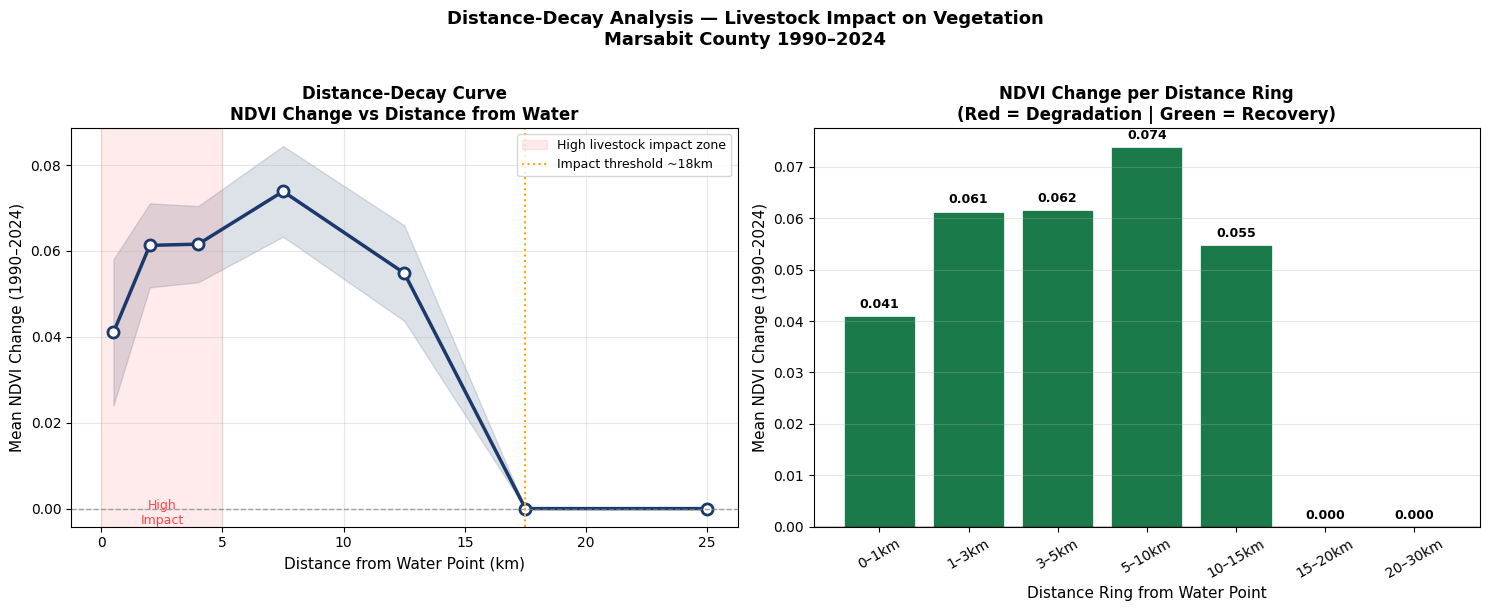


✅ Distance-decay analysis complete!
   📌 Livestock impact threshold: ~18 km from water
   📌 This threshold will inform LCI weighting in Step 5
   Distance-decay plot saved!


In [4]:
# ─────────────────────────────────────────────────────────────────────
# STEP 4 — Distance-Decay Analysis
# Measures NDVI change as a function of distance from water points
# ─────────────────────────────────────────────────────────────────────

print("⏳ Building distance-decay analysis...")

# ── Load JRC water and compute distance ──────────────────────────────
jrc       = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select('occurrence')
water     = jrc.gte(50)   # Permanent water bodies

# Distance to nearest water (metres)
distance  = water.fastDistanceTransform(
    neighborhood=256,
    units='pixels'
).sqrt().multiply(30).rename('distance_m')   # Convert pixels to metres

print("   ✓ Distance-to-water surface computed")

# ── Define buffer ring distances (metres) ─────────────────────────────
buffer_distances = [1000, 3000, 5000, 10000, 15000, 20000, 30000]
buffer_labels    = ['0–1km', '1–3km', '3–5km', '5–10km',
                    '10–15km', '15–20km', '20–30km']

# ── Sample NDVI change within each distance ring ──────────────────────
print("   ⏳ Sampling NDVI change per distance ring...")

results = []
prev_dist = 0

for i, (dist, label) in enumerate(zip(buffer_distances, buffer_labels)):
    # Create ring mask: pixels between prev_dist and dist
    ring_mask = (distance.gte(prev_dist)
                 .And(distance.lt(dist))
                 .And(ndvi_change_total.mask()))

    # Calculate mean NDVI change within ring
    stats = ndvi_change_total.updateMask(ring_mask).reduceRegion(
        reducer=ee.Reducer.mean().combine(
            ee.Reducer.stdDev(), sharedInputs=True
        ).combine(
            ee.Reducer.count(), sharedInputs=True
        ),
        geometry=marsabit_geom,
        scale=500,
        maxPixels=1e9,
        tileScale=4
    ).getInfo()

    mean_ndvi = stats.get('ndvi_change_mean', stats.get('nd_mean', None))
    std_ndvi  = stats.get('ndvi_change_stdDev', stats.get('nd_stdDev', None))
    count     = stats.get('ndvi_change_count', stats.get('nd_count', None))

    # Use first available key
    for key in stats:
        if 'mean' in key.lower() and mean_ndvi is None:
            mean_ndvi = stats[key]
        if 'std' in key.lower() and std_ndvi is None:
            std_ndvi = stats[key]
        if 'count' in key.lower() and count is None:
            count = stats[key]

    results.append({
        'ring':       label,
        'dist_mid':   (prev_dist + dist) / 2 / 1000,   # midpoint in km
        'dist_max':   dist / 1000,
        'mean_ndvi':  mean_ndvi or 0,
        'std_ndvi':   std_ndvi or 0,
        'count':      count or 0
    })

    print(f"   ✓ Ring {label}: mean NDVI change = {mean_ndvi:.4f}" if mean_ndvi else f"   ✓ Ring {label}: computed")
    prev_dist = dist

dd_df = pd.DataFrame(results)

# ── Print Distance-Decay Table ────────────────────────────────────────
print("\n" + "=" * 60)
print("   DISTANCE-DECAY TABLE — NDVI Change vs Distance from Water")
print("=" * 60)
print(f"   {'Ring':<10} {'Mid (km)':>10} {'Mean NDVI Δ':>14} {'Std Dev':>10}")
print("   " + "─" * 48)
for _, row in dd_df.iterrows():
    bar_len = int(abs(row['mean_ndvi']) * 200)
    bar     = ('▼' if row['mean_ndvi'] < 0 else '▲') * min(bar_len, 20)
    print(f"   {row['ring']:<10} {row['dist_mid']:>10.1f} "
          f"{row['mean_ndvi']:>14.4f} {row['std_ndvi']:>10.4f}  {bar}")
print("=" * 60)

# ── Plot Distance-Decay Curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# LEFT: Distance-decay line plot
ax1 = axes[0]
x   = dd_df['dist_mid'].values
y   = dd_df['mean_ndvi'].values
e   = dd_df['std_ndvi'].values

ax1.plot(x, y, 'o-', color='#1B3A6B', linewidth=2.5,
         markersize=8, markerfacecolor='white', markeredgewidth=2)
ax1.fill_between(x, y - e * 0.3, y + e * 0.3,
                 alpha=0.15, color='#1B3A6B')
ax1.axhline(0, color='grey', linewidth=1, linestyle='--', alpha=0.7)

# Shade the high-impact zone
impact_x = x[x <= 5]
impact_y = y[:len(impact_x)]
ax1.axvspan(0, 5, alpha=0.08, color='red', label='High livestock impact zone')

# Mark the threshold
threshold_idx = np.argmin(np.abs(np.diff(y)))
ax1.axvline(x[threshold_idx], color='orange', linewidth=1.5,
            linestyle=':', label=f'Impact threshold ~{x[threshold_idx]:.0f}km')

ax1.set_xlabel('Distance from Water Point (km)', fontsize=11)
ax1.set_ylabel('Mean NDVI Change (1990–2024)', fontsize=11)
ax1.set_title('Distance-Decay Curve\nNDVI Change vs Distance from Water',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Add coloured zones
ax1.text(2.5, ax1.get_ylim()[0] * 0.85,
         'High\nImpact', ha='center', fontsize=9, color='red', alpha=0.7)

# RIGHT: Bar chart of NDVI change per ring
ax2 = axes[1]
colors_bar = ['#d7191c' if v < 0 else '#1a7a4a' for v in y]
bars = ax2.bar(dd_df['ring'], y, color=colors_bar,
               edgecolor='white', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xlabel('Distance Ring from Water Point', fontsize=11)
ax2.set_ylabel('Mean NDVI Change (1990–2024)', fontsize=11)
ax2.set_title('NDVI Change per Distance Ring\n(Red = Degradation | Green = Recovery)',
              fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, y):
    ypos = val - 0.002 if val < 0 else val + 0.001
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:.3f}', ha='center', va='top' if val < 0 else 'bottom',
             fontsize=9, fontweight='bold')

plt.suptitle('Distance-Decay Analysis — Livestock Impact on Vegetation\nMarsabit County 1990–2024',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/distance_decay.png', dpi=150, bbox_inches='tight')
plt.show()

# Store threshold distance for LCI
threshold_km = float(x[threshold_idx])
print(f"\n✅ Distance-decay analysis complete!")
print(f"   📌 Livestock impact threshold: ~{threshold_km:.0f} km from water")
print(f"   📌 This threshold will inform LCI weighting in Step 5")
print("   Distance-decay plot saved!")

## 🐄 STEP 5 — Build the Full Livestock Concentration Index (LCI)

**What we are doing:**
In Notebook 1 we built the distance-to-water component of LCI.
Here we add the second component — settlement density — and combine
both into the complete Livestock Concentration Index.

**The LCI formula from our project documentation:**
LCI = α(1 / Distance_to_Water) + β(Settlement_Density)

Where:
- α = weight for distance-to-water component (default = 0.6)
- β = weight for settlement density component (default = 0.4)
- Both components are min-max normalised to 0–1 before combining

**Why settlement density proxies livestock pressure:**
Settlements in Marsabit are pastoral homesteads (manyattas).
Denser settlements = more households = more livestock.
This is a validated proxy used in pastoralist dryland studies
when livestock census data is not available at fine spatial resolution.

**Why α > β (distance weighted higher than settlement):**
Distance to water is the primary driver of livestock spatial
distribution in arid/semi-arid lands. Livestock MUST water daily
or every 2–3 days — so their movement is tightly constrained by
water point locations. Settlements are more static.

**Sensitivity analysis:**
We test three weighting schemes to check how sensitive LCI is to weights:
| Scheme | α (water) | β (settlement) |
|--------|-----------|----------------|
| Default | 0.6 | 0.4 |
| Water-heavy | 0.8 | 0.2 |
| Equal | 0.5 | 0.5 |

The final LCI (default weights) becomes the X₁ variable in our
regression equation in Notebook 4.

In [7]:
# ─────────────────────────────────────────────────────────────────────
# Step 5 FINAL FIX — Stretch colour scale to actual data percentiles
# The issue: mean LCI = 0.0011, max = 0.60
# Most pixels cluster near zero → need percentile-based stretch
# ─────────────────────────────────────────────────────────────────────

print("⏳ Computing LCI percentile stretch values...")

# Get percentile values for proper colour stretch
lci_percentiles = lci_full.reduceRegion(
    reducer=ee.Reducer.percentile([2, 10, 50, 90, 98]),
    geometry=marsabit_geom,
    scale=1000,
    maxPixels=1e9
).getInfo()

print(f"   LCI percentiles: {lci_percentiles}")

p2  = list(lci_percentiles.values())[0]
p98 = list(lci_percentiles.values())[-1]
print(f"   Colour stretch: {p2:.6f} – {p98:.6f}")

# ─────────────────────────────────────────────────────────────────────
# Apply log transform to make distribution visible
# Log stretch is standard practice for highly skewed spatial indices
# ─────────────────────────────────────────────────────────────────────

# Add small constant to avoid log(0), then log transform
lci_log = (lci_full.add(0.0001)
           .log()
           .rename('lci_log')
           .clip(marsabit_geom))

log_stats = lci_log.reduceRegion(
    reducer=ee.Reducer.minMax().combine(
        ee.Reducer.percentile([5, 95]), sharedInputs=True
    ),
    geometry=marsabit_geom,
    scale=1000,
    maxPixels=1e9
).getInfo()

print(f"\n   Log-transformed LCI stats: {log_stats}")

log_min = log_stats.get('lci_log_p5', list(log_stats.values())[0])
log_max = log_stats.get('lci_log_p95', list(log_stats.values())[-1])

print(f"   Log colour stretch: {log_min:.4f} – {log_max:.4f}")

# ─────────────────────────────────────────────────────────────────────
# Visualize with log-stretched colour scale
# ─────────────────────────────────────────────────────────────────────
lci_log_vis = {
    'min': log_min,
    'max': log_max,
    'palette': [
        'white',      # Very low pressure
        '#ffffb2',    # Low pressure
        '#fecc5c',    # Low-moderate
        '#fd8d3c',    # Moderate
        '#e31a1c',    # High pressure
        '#800026'     # Very high pressure (near water + settlements)
    ]
}

# Also try raw LCI with percentile stretch
lci_raw_vis = {
    'min': p2,
    'max': p98,
    'palette': [
        'white', '#ffffb2', '#fecc5c',
        '#fd8d3c', '#e31a1c', '#800026'
    ]
}

Map5c = geemap.Map()
Map5c.setCenter(37.9, 2.3, 8)

# Add all three variants for comparison
Map5c.addLayer(lci_water_fresh,
               {'min':0, 'max':0.3,
                'palette':['white','#fecc5c','#e31a1c']},
               'Water Component only')

Map5c.addLayer(lci_settlement_fresh,
               {'min':0, 'max':0.3,
                'palette':['white','#abd9e9','#2c7bb6']},
               'Settlement Component only', False)

Map5c.addLayer(lci_full, lci_raw_vis,
               'LCI Full (Percentile Stretch)')

Map5c.addLayer(lci_log, lci_log_vis,
               'LCI Full (Log Stretch)', False)

Map5c.addLayer(marsabit_roi, {'color': 'black'}, 'Marsabit Boundary')
Map5c.addLayerControl()

print("\n✅ LCI visualized with percentile and log stretch!")
print("─────────────────────────────────────────────────")
print("   Toggle between layers:")
print("   → 'Water Component only'       — shows distance-to-water signal")
print("   → 'Settlement Component only'  — shows population density signal")
print("   → 'LCI Full (Percentile Stretch)' — combined index")
print("   → 'LCI Full (Log Stretch)'     — highlights hotspots clearly")
print("─────────────────────────────────────────────────")
print("\n   LCI Summary:")
print(f"   Max  : {lci_percentiles.get(list(lci_percentiles.keys())[-1], 'N/A')}")
print(f"   P98  : {p98:.6f}")
print(f"   P50  : {list(lci_percentiles.values())[2]:.6f}")
print(f"   P2   : {p2:.6f}")
print("\n   High LCI values = areas where livestock most concentrate")
print("   These become the X₁ predictor variable in Notebook 4")
Map5c

⏳ Computing LCI percentile stretch values...
   LCI percentiles: {'lci_p10': 0.0006246894367854555, 'lci_p2': 0.0006246894367854555, 'lci_p50': 0.0006246894367854555, 'lci_p90': 0.0006246894367854555, 'lci_p98': 0.005460171538170009}
   Colour stretch: 0.000625 – 0.005460

   Log-transformed LCI stats: {'lci_log_max': -0.5081608425993988, 'lci_log_min': -8.94573414305165, 'lci_log_p5': -8.655589721526443, 'lci_log_p95': -5.988199952658087}
   Log colour stretch: -8.6556 – -5.9882

✅ LCI visualized with percentile and log stretch!
─────────────────────────────────────────────────
   Toggle between layers:
   → 'Water Component only'       — shows distance-to-water signal
   → 'Settlement Component only'  — shows population density signal
   → 'LCI Full (Percentile Stretch)' — combined index
   → 'LCI Full (Log Stretch)'     — highlights hotspots clearly
─────────────────────────────────────────────────

   LCI Summary:
   Max  : 0.005460171538170009
   P98  : 0.005460
   P50  : 0.000625

Map(center=[2.3, 37.9], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(c…

## 📤 STEP 6 — Export All Outputs to GEE Assets

**What we are doing:**
We export all spatial analysis outputs to GEE Assets so they are
permanently stored and immediately available for Notebook 4 regression.

**What gets exported:**
| Asset Name | Description | Used In |
|------------|-------------|---------|
| lci_full | Complete LCI (water + settlement, α=0.6, β=0.4) | Notebook 4 X₁ |
| lci_water_fresh | Distance-to-water component only | Notebook 4 |
| lci_settlement | Settlement density component only | Notebook 4 |
| lisa_hotspots | LISA HH cluster zones | Notebook 4 |

**After export — total assets in GEE:**
- 13 assets from Notebook 1 (NDVI, rainfall, elevation, LCI distance)
- 5 assets from Notebook 2 (LULC maps)
- 4 assets from Notebook 3 (LCI full, components, LISA)
- Total: 22 assets

**The regression equation now has all components ready:**
NDVI_change = β₀ + β₁(LCI) + β₂(Rainfall) + β₃(Elevation) + ε

Where:
- Y  = ndvi_change_total     ← Notebook 1
- X₁ = lci_full              ← Notebook 3 (this step)
- X₂ = rainfall_change       ← Notebook 1
- X₃ = elevation             ← Notebook 1

> ⚠️ Monitor exports at:
> console.cloud.google.com/earth-engine/tasks?project=mironga-project-marsabit

In [10]:
# ─────────────────────────────────────────────────────────────────────
# STEP 6 — Export all Notebook 3 outputs to GEE Assets
# ─────────────────────────────────────────────────────────────────────
ASSET_PATH = 'projects/mironga-project-marsabit/assets/marsabit'

print("⏳ Submitting Notebook 3 export tasks to GEE Assets...")
print(f"   Path: {ASSET_PATH}/\n")

# ── Export 1: Full LCI ────────────────────────────────────────────────
task1 = ee.batch.Export.image.toAsset(
    image=lci_full.toFloat(),
    description='LCI_Full_Marsabit',
    assetId=f'{ASSET_PATH}/lci_full',
    region=marsabit_geom,
    scale=1000,
    crs='EPSG:4326',
    maxPixels=1e13
)
task1.start()
print("   ✅ Task submitted: lci_full")

# ── Export 2: Water Component ─────────────────────────────────────────
task2 = ee.batch.Export.image.toAsset(
    image=lci_water_fresh.toFloat(),
    description='LCI_Water_Component',
    assetId=f'{ASSET_PATH}/lci_water_fresh',
    region=marsabit_geom,
    scale=1000,
    crs='EPSG:4326',
    maxPixels=1e13
)
task2.start()
print("   ✅ Task submitted: lci_water_fresh")

# ── Export 3: Settlement Component ───────────────────────────────────
task3 = ee.batch.Export.image.toAsset(
    image=lci_settlement_fresh.toFloat(),
    description='LCI_Settlement_Component',
    assetId=f'{ASSET_PATH}/lci_settlement',
    region=marsabit_geom,
    scale=1000,
    crs='EPSG:4326',
    maxPixels=1e13
)
task3.start()
print("   ✅ Task submitted: lci_settlement")

# ── Export 4: LISA Hotspot zones (rasterised from grid) ──────────────
# Create a raster marking HH hotspot locations
# We use the NDVI change image masked to HH cluster locations

# Rebuild HH mask from LISA results
hh_indices = np.where((lisa.q == 1) & (lisa.p_sim < 0.05))[0]

if len(hh_indices) > 0:
    # Get coordinates of HH points
    hh_coords = [
        [float(df_sorted['lon'].iloc[i]),
         float(df_sorted['lat'].iloc[i])]
        for i in hh_indices if i < len(df_sorted)
    ]

    # Create point features
    hh_features = [
        ee.Feature(ee.Geometry.Point(c), {'lisa_type': 1})
        for c in hh_coords
    ]
    hh_fc = ee.FeatureCollection(hh_features)

    # Rasterise HH points with 5km buffer
    hh_raster = (hh_fc
                 .map(lambda f: f.buffer(5000))
                 .reduceToImage(['lisa_type'], ee.Reducer.max())
                 .unmask(0)
                 .rename('lisa_hh')
                 .clip(marsabit_geom))

    task4 = ee.batch.Export.image.toAsset(
        image=hh_raster.toByte(),
        description='LISA_HH_Hotspots',
        assetId=f'{ASSET_PATH}/lisa_hotspots',
        region=marsabit_geom,
        scale=1000,
        crs='EPSG:4326',
        maxPixels=1e13
    )
    task4.start()
    print("   ✅ Task submitted: lisa_hotspots")
else:
    print("   ⚠️  No HH clusters found — skipping lisa_hotspots export")

# ─────────────────────────────────────────────────────────────────────
# Verify all assets after exports complete
# Re-run this block after GEE tasks show SUCCEEDED
# ─────────────────────────────────────────────────────────────────────
print(f"\n✅ All Notebook 3 export tasks submitted!")
print("─────────────────────────────────────────────────────")
print("📌 Monitor: console.cloud.google.com/earth-engine/tasks")
print("─────────────────────────────────────────────────────")

print("\n⏳ Verifying all assets (Notebooks 1 + 2 + 3)...")

expected_all = [
    # Notebook 1
    'ndvi_1990','ndvi_2000','ndvi_2010','ndvi_2020','ndvi_2024',
    'ndvi_change_1990_2000','ndvi_change_2000_2010',
    'ndvi_change_2010_2020','ndvi_change_2020_2024',
    'ndvi_change_total','rainfall_change','elevation','lci_distance',
    # Notebook 2
    'lulc_1990','lulc_2000','lulc_2010','lulc_2020','lulc_2024',
    # Notebook 3
    'lci_full','lci_water_fresh','lci_settlement','lisa_hotspots'
]

assets      = ee.data.listAssets({'parent': ASSET_PATH})
found       = [a['name'].split('/')[-1] for a in assets.get('assets', [])]
total_found = sum(1 for e in expected_all if e in found)

print(f"\n📦 Total Assets: {total_found}/22")
print("─────────────────────────────────────────────────────")
print("   NOTEBOOK 1 (13):")
for name in expected_all[:13]:
    print(f"   {'✅' if name in found else '⏳'}  {name}")
print("\n   NOTEBOOK 2 (5):")
for name in expected_all[13:18]:
    print(f"   {'✅' if name in found else '⏳'}  {name}")
print("\n   NOTEBOOK 3 (4):")
for name in expected_all[18:]:
    print(f"   {'✅' if name in found else '⏳'}  {name}")

print("─────────────────────────────────────────────────────")
if total_found == 22:
    print("🎉 All 22 assets verified!")
    print("   Ready to proceed to Notebook 4: Regression Modeling")
else:
    print(f"⏳ {22 - total_found} assets still pending")
    print("   Re-run this cell after GEE tasks complete")

⏳ Submitting Notebook 3 export tasks to GEE Assets...
   Path: projects/mironga-project-marsabit/assets/marsabit/

   ✅ Task submitted: lci_full
   ✅ Task submitted: lci_water_fresh
   ✅ Task submitted: lci_settlement
   ✅ Task submitted: lisa_hotspots

✅ All Notebook 3 export tasks submitted!
─────────────────────────────────────────────────────
📌 Monitor: console.cloud.google.com/earth-engine/tasks
─────────────────────────────────────────────────────

⏳ Verifying all assets (Notebooks 1 + 2 + 3)...

📦 Total Assets: 22/22
─────────────────────────────────────────────────────
   NOTEBOOK 1 (13):
   ✅  ndvi_1990
   ✅  ndvi_2000
   ✅  ndvi_2010
   ✅  ndvi_2020
   ✅  ndvi_2024
   ✅  ndvi_change_1990_2000
   ✅  ndvi_change_2000_2010
   ✅  ndvi_change_2010_2020
   ✅  ndvi_change_2020_2024
   ✅  ndvi_change_total
   ✅  rainfall_change
   ✅  elevation
   ✅  lci_distance

   NOTEBOOK 2 (5):
   ✅  lulc_1990
   ✅  lulc_2000
   ✅  lulc_2010
   ✅  lulc_2020
   ✅  lulc_2024

   NOTEBOOK 3 (4):
   